### Import Dependencies

In [1]:
from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

Single Node Graph

In [2]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str

In [14]:
def append_vibes_to_query(state: State) -> dict:

    return {
        "answer": f"{state.message} {state.vibe}"
    }

In [15]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()

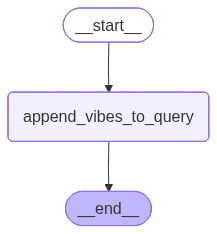

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}

In [7]:
result = graph.invoke(initial_state)

In [8]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

In [9]:
initial_state = {
    "message": "Give me some vibes!",
    "answer": "abc",
    "vibe": "I'm feeling like a badass today!"
}

In [10]:
result = graph.invoke(initial_state)

In [11]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

### Conditional Graph

In [12]:
class State(BaseModel):
    message: str
    answer: str = ""

In [13]:
def append_vibes_to_query(state: State) -> dict:

    return {
        "answer": state.message
    }

In [18]:
def append_vibe_1(state: State) -> dict:

    vibe = "I'm feeling like a badass today!"

    return {
        "answer": f"{state.message} {vibe}"
    }


def append_vibe_2(state: State) -> dict:

    vibe = "I'm feeling like a boss today!"

    return {
        "answer": f"{state.message} {vibe}"
    }


def append_vibe_3(state: State) -> dict:

    vibe = "I'm feeling like a legend today!"

    return {
        "answer": f"{state.message} {vibe}"
    }

In [19]:
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:

    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]

    vibe_path = random.choice(vibes)

    return vibe_path

In [20]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

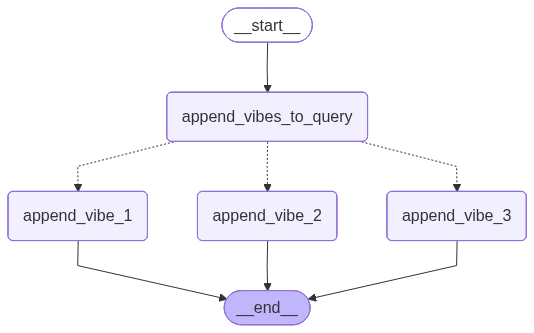

In [21]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
initial_state = {
    "message": "I am here to add some vibes:"
}

In [31]:
result = graph.invoke(initial_state)

In [30]:
result

{'message': 'I am here to add some vibes:',
 'answer': "I am here to add some vibes: I'm feeling like a boss today!"}

In [29]:
result = graph.invoke(initial_state)

In [28]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

In [27]:
workflow = StateGraph(State)

workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    START,
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

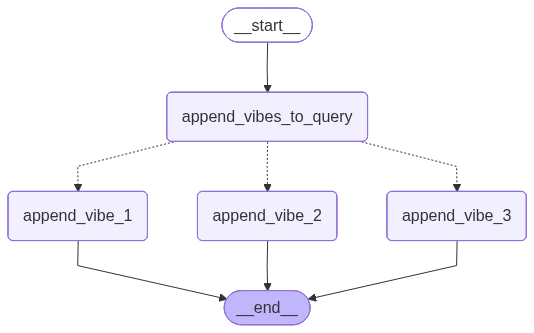

In [26]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
result = graph.invoke(initial_state)

In [24]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

### Exploring LangChain Tool Calling

In [23]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

In [34]:
@tool
def dummy_tool(a: str, b: str) -> str:

    """Concatenate two strings.
    
    Args:
        a: The first string to concatenate
        b: The second string to concatenate
    
    Returns:
        A string of the two strings concatenated.
    """

    return f"Hello {a} and {b}"

In [35]:
llm = ChatOpenAI(
    model="gpt-5.4-mini",
    reasoning_effort="none",
    use_responses_api=True
)
llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto"
)

In [36]:
response = llm_with_tools.invoke("Use dummy tool to concatenate two random words")

In [37]:
response

AIMessage(content=[{'arguments': '{"a":"sun","b":"flower"}', 'call_id': 'call_awBdfVtr5Dw46EBs6KVKZhPu', 'name': 'dummy_tool', 'type': 'function_call', 'id': 'fc_00d6e59b0340dc72006a54e864b670819c9e50c003d1c6c3fd', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_00d6e59b0340dc72006a54e863d568819cb96e38ea23d3d7d6', 'created_at': 1783949411.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_00d6e59b0340dc72006a54e863d568819cb96e38ea23d3d7d6', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'sun', 'b': 'flower'}, 'id': 'call_awBdfVtr5Dw46EBs6KVKZhPu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 84, 'output_tokens': 23, 'total_tokens': 107, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [38]:
response.usage_metadata

{'input_tokens': 84,
 'output_tokens': 23,
 'total_tokens': 107,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [39]:
response.tool_calls

[{'name': 'dummy_tool',
  'args': {'a': 'sun', 'b': 'flower'},
  'id': 'call_awBdfVtr5Dw46EBs6KVKZhPu',
  'type': 'tool_call'}]

### Agent Graph

In [40]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    
    return f"{query} {vibe}"

In [41]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [42]:
def agent_node(state: State) -> dict:
    
    prompt_template = """You are an assistant that is generating vibes for a user.

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.

## User Query
{{ query }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.query
    )

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [append_vibes],
        tool_choice="auto"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt)
        ]
    )

    return {
        "messages": [response]
    }


In [43]:
def tool_router(state: State) -> str:

    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [44]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_edge(START, "agent_node")

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", END)

graph = workflow.compile()

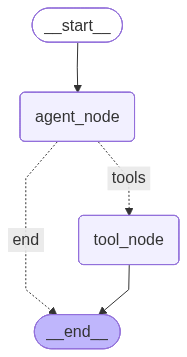

In [45]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
initial_state = {
    "query": "Give me some vibes!"
}

In [47]:
result = graph.invoke(initial_state)

In [48]:
result

{'query': 'Give me some vibes!',
 'messages': [AIMessage(content=[{'arguments': '{"query":"Give me some vibes!","vibe":"with a dreamy, neon-soaked, late-night city glow"}', 'call_id': 'call_94S01JwO3mM38I3ZYUqV17hg', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0e47039ccc0b9dc4006a54ecef232881a18c50cae9cdcadae1', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0e47039ccc0b9dc4006a54ecee887c81a19ac410d1d9d37280', 'created_at': 1783950574.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0e47039ccc0b9dc4006a54ecee887c81a19ac410d1d9d37280', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'with a dreamy, neon-soaked, late-night city glow'}, 'id': 'call_94S01JwO3mM38I3ZYUqV17hg', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 

### Agent Graph with Loopback from Tools (ReAct Agent)

In [58]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    
    return f"{query} {vibe}"

In [59]:
class FinalResponse(BaseModel):
    answer: str

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [60]:
def agent_node(state: State) -> dict:
    
    prompt_template = """You are an assistant that is generating vibes for a user.

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
- You must return a tool call in the first interaction.
"""

    template = Template(prompt_template)

    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [append_vibes, FinalResponse],
        tool_choice="auto"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")

    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer
    }


In [52]:
def tool_router(state: State) -> str:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [53]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

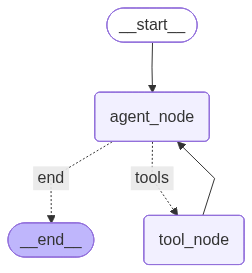

In [54]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [55]:
initial_state = {}

In [56]:
result = graph.invoke(initial_state)

In [57]:
result

{'messages': [AIMessage(content=[{'arguments': '{"query":"Add a random vibe to the user\'s query.","vibe":"with a playful, cosmic sparkle"}', 'call_id': 'call_OXnEFw31QYzl6cXxAlGqT3vP', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0f70ad9c967c026a006a54ee24d824819281d4caf525d97139', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0f70ad9c967c026a006a54ee243918819294e36563a9f84991', 'created_at': 1783950884.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0f70ad9c967c026a006a54ee243918819294e36563a9f84991', tool_calls=[{'name': 'append_vibes', 'args': {'query': "Add a random vibe to the user's query.", 'vibe': 'with a playful, cosmic sparkle'}, 'id': 'call_OXnEFw31QYzl6cXxAlGqT3vP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 158, 'output_tokens': 36, 'tot